In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sohanuuu/models/robust_resnet18.pth
/kaggle/input/datasets/sohanuuu/models/standard_resnet18.pth
/kaggle/input/competitions/cifar-10/trainLabels.csv
/kaggle/input/competitions/cifar-10/sampleSubmission.csv
/kaggle/input/competitions/cifar-10/test.7z
/kaggle/input/competitions/cifar-10/train.7z


# Notebook 4 — Evaluation, Grad-CAM & LIME Analysis

**Goal:** Definitive performance evaluation + full interpretability layer (Grad-CAM + LIME) + per-class analysis + deployment export.

**Sections:**
1. Setup & data loading
2. Attack engine (FGSM & PGD)
3. Full comparison table (CSV export)
4. Robustness curve (epsilon sweep)
5. Grad-CAM setup
6. Grad-CAM 3-scenario visualisation
7. Grad-CAM batch export
8. Per-image prediction grid
9. Per-class robustness analysis
10. Visual examples with prediction tables
11. LIME model-agnostic explanations
12. Key insights & findings
13. Export for deployment


---
## Cell 0 — Install Interpretability Requirements
Requires `grad-cam` library which isn't dynamically installed by default globally.

In [2]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 69.1 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=372da3d8c6b72986128c73a802d6ce9c5c981295f08bc8ec6b046be8c80105b9
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


---
## Cell 1 — Setup Environment, Load Data & Checkpoints

In [3]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import subprocess
import os
import time
import glob
import json

# ── Reproducibility ──
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── PGD eval steps (consistent with NB3) ──
PGD_EPSILON    = 8/255.0
PGD_ALPHA      = 2/255.0
# PGD_EVAL_STEPS = 10

# ── Paths ──
KAGGLE_INPUT  = '/kaggle/input/competitions/cifar-10'
LABELS_CSV    = f'{KAGGLE_INPUT}/trainLabels.csv'
TRAIN_ARCHIVE = f'{KAGGLE_INPUT}/train.7z'
EXTRACT_DIR   = '/kaggle/working/cifar10_extracted'
TRAIN_IMG_DIR = f'{EXTRACT_DIR}/train'

OUTPUT_DIR  = '/kaggle/working/outputs'
GRADCAM_DIR = f'{OUTPUT_DIR}/gradcam'
os.makedirs(GRADCAM_DIR, exist_ok=True)

# Direct checkpoint paths — both downloaded from NB1/NB3 Kaggle outputs
STANDARD_CHECKPOINT_PATH = '/kaggle/input/datasets/sohanuuu/models/standard_resnet18.pth'
ROBUST_CHECKPOINT_PATH   = '/kaggle/input/datasets/sohanuuu/models/robust_resnet18.pth'

print(f"Training on: {DEVICE}")

Training on: cuda


In [4]:
# ── Extract if needed ──
if not os.path.exists(TRAIN_IMG_DIR) or len(os.listdir(TRAIN_IMG_DIR)) == 0:
    print('Extracting train images...')
    subprocess.run(['7z', 'x', TRAIN_ARCHIVE, f'-o{EXTRACT_DIR}', '-y'], stdout=subprocess.DEVNULL)
    print('Done.')
else:
    print(f'Images already extracted: {len(os.listdir(TRAIN_IMG_DIR)):,} files')

Extracting train images...
Done.


In [5]:
# ── CIFAR-10 constants ──
CIFAR10_MEAN    = (0.4914, 0.4822, 0.4465)
CIFAR10_STD     = (0.2023, 0.1994, 0.2010)
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
CLASS_TO_IDX    = {cls: idx for idx, cls in enumerate(CIFAR10_CLASSES)}

# ── Dataset (identical to NB1/NB2/NB3) ──
class CIFAR10Dataset(Dataset):
    def __init__(self, image_ids, labels, img_dir, transform=None):
        self.image_ids = image_ids
        self.labels    = labels
        self.img_dir   = img_dir
        self.transform = transform
    def __len__(self): return len(self.image_ids)
    def __getitem__(self, idx):
        image = Image.open(os.path.join(self.img_dir, f'{self.image_ids[idx]}.png')).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, self.labels[idx]

# ── Recreate exact same splits as NB1/NB2/NB3 — full 5000 test set ──
labels_df  = pd.read_csv(LABELS_CSV)
all_ids    = labels_df['id'].values
all_labels = labels_df['label'].map(CLASS_TO_IDX).values

_, temp_ids, _, temp_labels = train_test_split(
    all_ids, all_labels, test_size=10000, random_state=SEED, stratify=all_labels
)
val_ids, test_ids, val_labels, test_labels = train_test_split(
    temp_ids, temp_labels, test_size=5000, random_state=SEED, stratify=temp_labels
)

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

test_dataset = CIFAR10Dataset(test_ids, test_labels, TRAIN_IMG_DIR, transform=eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=2, pin_memory=True)
print(f'Test samples : {len(test_dataset):,}  (full held-out set)')

# ── Model definition ──
def create_resnet18_cifar10():
    model = models.resnet18(weights=None)
    model.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc     = nn.Linear(512, 10)
    return model

# ── Load both checkpoints ──
standard_model = create_resnet18_cifar10().to(DEVICE)
robust_model   = create_resnet18_cifar10().to(DEVICE)

standard_model.load_state_dict(torch.load(STANDARD_CHECKPOINT_PATH, map_location=DEVICE, weights_only=True))
robust_model.load_state_dict(torch.load(ROBUST_CHECKPOINT_PATH,   map_location=DEVICE, weights_only=True))

standard_model.eval()
robust_model.eval()

print(f'Standard checkpoint : {STANDARD_CHECKPOINT_PATH}')
print(f'Robust checkpoint   : {ROBUST_CHECKPOINT_PATH}')
print('Both models loaded successfully.')

Test samples : 5,000  (full held-out set)
Standard checkpoint : /kaggle/input/datasets/sohanuuu/models/standard_resnet18.pth
Robust checkpoint   : /kaggle/input/datasets/sohanuuu/models/robust_resnet18.pth
Both models loaded successfully.


---
## Cell 2 — Attack Engine Methods (FGSM & PGD)
We need both standard attacks for unified benchmarking.

In [10]:
def denormalize(tensor):
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1).to(tensor.device)
    std  = torch.tensor(CIFAR10_STD).view(3, 1, 1).to(tensor.device)
    return tensor * std + mean

def normalize(tensor):
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1).to(tensor.device)
    std  = torch.tensor(CIFAR10_STD).view(3, 1, 1).to(tensor.device)
    return (tensor - mean) / std

def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(DEVICE)
    labels = labels.to(DEVICE)
    images.requires_grad = True
    loss = nn.CrossEntropyLoss()(model(images), labels)
    model.zero_grad()
    loss.backward()
    adv = torch.clamp(denormalize(images) + epsilon * images.grad.data.sign(), 0, 1)
    return normalize(adv).detach()

def pgd_attack(model, images, labels, epsilon=PGD_EPSILON, alpha=PGD_ALPHA, steps=PGD_EVAL_STEPS):
    """
    PGD attack. Defaults to PGD_EVAL_STEPS=10 for all evaluation in this notebook.
    """
    images, labels  = images.clone().detach().to(DEVICE), labels.to(DEVICE)
    orig_denorm     = denormalize(images).clone().detach()
    adv             = images.clone().detach()

    for _ in range(steps):
        adv.requires_grad = True
        loss = nn.CrossEntropyLoss()(model(adv), labels)
        model.zero_grad()
        loss.backward()
        adv_denorm = denormalize(adv) + alpha * adv.grad.data.sign()
        eta        = torch.clamp(adv_denorm - orig_denorm, -epsilon, epsilon)
        adv        = normalize(torch.clamp(orig_denorm + eta, 0, 1)).detach()

    return adv

def evaluate_attack(model, loader, attack_fn=None, **kwargs):
    """Clean eval if attack_fn=None, adversarial otherwise."""
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        adv = attack_fn(model, images, labels, **kwargs) if attack_fn else images.to(DEVICE)
        with torch.no_grad():
            _, predicted = model(adv).max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels.to(DEVICE)).sum().item()
    return 100.0 * correct / total

print('Attack functions defined. PGD defaults: epsilon=8/255, alpha=2/255, steps=10')


Attack functions defined. PGD defaults: epsilon=8/255, alpha=2/255, steps=10


---
## Cell 3 — Full Comparison Table
Pitting both models strictly against the isolated evaluation test set limits.

In [11]:
print('Evaluating on full 5,000 held-out test images...\n')

results = {
    'Clean accuracy': {
        'Standard': evaluate_attack(standard_model, test_loader),
        'Robust'  : evaluate_attack(robust_model,   test_loader)
    },
    'FGSM accuracy (eps=8/255)': {
        'Standard': evaluate_attack(standard_model, test_loader, fgsm_attack, epsilon=8/255),
        'Robust'  : evaluate_attack(robust_model,   test_loader, fgsm_attack, epsilon=8/255)
    },
    'PGD-5 accuracy (eps=8/255)': {
        'Standard': evaluate_attack(standard_model, test_loader, pgd_attack, steps=5),
        'Robust'  : evaluate_attack(robust_model,   test_loader, pgd_attack, steps=5)
    },
    'PGD-10 accuracy (eps=8/255)': {
        'Standard': evaluate_attack(standard_model, test_loader, pgd_attack, steps=10),
        'Robust'  : evaluate_attack(robust_model,   test_loader, pgd_attack, steps=10)
    }
}

print(f"{'Scenario':<30} | {'Standard':>10} | {'Robust':>8}")
print('=' * 56)
for scenario, m_res in results.items():
    print(f"{scenario:<30} | {m_res['Standard']:>9.2f}% | {m_res['Robust']:>7.2f}%")

with open(f'{OUTPUT_DIR}/comparison_results.json', 'w') as f:
    json.dump(results, f, indent=4)
print(f'\nSaved to: {OUTPUT_DIR}/comparison_results.json')

# ── Pretty display + CSV export ──
scenarios = list(results.keys())
std_vals  = [results[s]['Standard'] for s in scenarios]
rob_vals  = [results[s]['Robust']   for s in scenarios]

results_df = pd.DataFrame({
    'Scenario' : scenarios,
    'Standard' : [f"{v:.2f}%" for v in std_vals],
    'Robust'   : [f"{v:.2f}%" for v in rob_vals],
})
results_df_num = pd.DataFrame({
    'Scenario' : scenarios,
    'Standard' : std_vals,
    'Robust'   : rob_vals,
})

print("\n── Final Evaluation Table ──")
print(results_df.to_string(index=False))

results_df_num.to_csv(f'{OUTPUT_DIR}/final_results.csv', index=False)
print(f"\nSaved CSV: {OUTPUT_DIR}/final_results.csv")


Evaluating on full 5,000 held-out test images...

Scenario                       |   Standard |   Robust
Clean accuracy                 |     92.94% |   87.36%
FGSM accuracy (eps=8/255)      |     15.88% |   52.72%
PGD-5 accuracy (eps=8/255)     |      0.10% |   45.94%
PGD-10 accuracy (eps=8/255)    |      0.02% |   42.58%

Saved to: /kaggle/working/outputs/comparison_results.json

── Final Evaluation Table ──
                   Scenario Standard Robust
             Clean accuracy   92.94% 87.36%
  FGSM accuracy (eps=8/255)   15.88% 52.72%
 PGD-5 accuracy (eps=8/255)    0.10% 45.94%
PGD-10 accuracy (eps=8/255)    0.02% 42.58%

Saved CSV: /kaggle/working/outputs/final_results.csv


---
## Cell 4 — Robustness Curve (Epsilon Sweep)

Running automated sweep of escalating capabilities. Please wait...


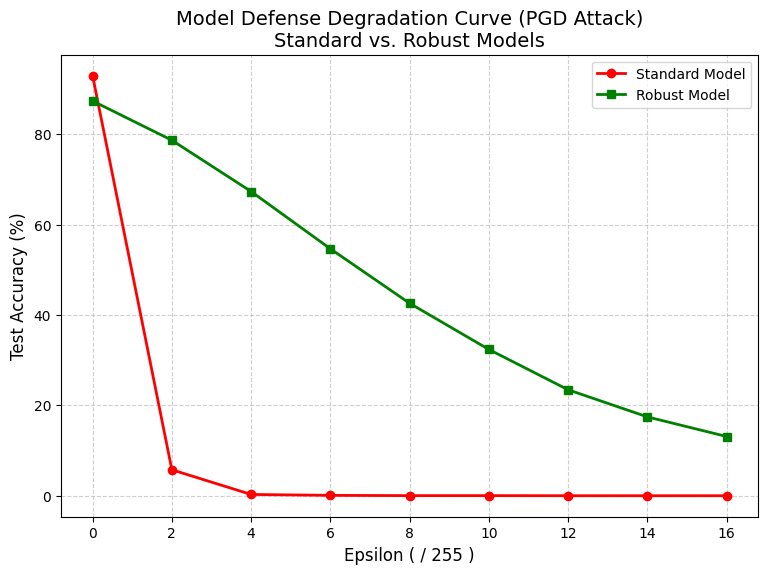

Plotted comparative sweep saved at /kaggle/working/outputs/gradcam/robustness_curve.png


In [8]:
epsilons = [0, 2, 4, 6, 8, 10, 12, 14, 16]
eps_floats = [e/255.0 for e in epsilons]

std_accs, rob_accs = [], []
print("Running automated sweep of escalating capabilities. Please wait...")
for eps in eps_floats:
    if eps == 0:
        std_accs.append(results["Clean accuracy"]["Standard"])
        rob_accs.append(results["Clean accuracy"]["Robust"])
    else:
        std_accs.append(evaluate_attack(standard_model, test_loader, pgd_attack, epsilon=eps))
        rob_accs.append(evaluate_attack(robust_model, test_loader, pgd_attack, epsilon=eps))
        
plt.figure(figsize=(9, 6))
plt.plot(epsilons, std_accs, 'o-', color='red', label='Standard Model', linewidth=2)
plt.plot(epsilons, rob_accs, 's-', color='green', label='Robust Model', linewidth=2)
plt.title("Model Defense Degradation Curve (PGD Attack)\nStandard vs. Robust Models", fontsize=14)
plt.xlabel("Epsilon ( / 255 )", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.xticks(epsilons)
plt.legend(); plt.grid(True, linestyle="--", alpha=0.6)

sweep_path = f'{GRADCAM_DIR}/robustness_curve.png'
plt.savefig(sweep_path, dpi=300)
plt.show()
print(f"Plotted comparative sweep saved at {sweep_path}")

---
## Cell 5 — Grad-CAM Setup

Attaching to `layer4[-1]` of ResNet-18 allows monitoring the final spatial reasoning dimensions before linear classification.

In [14]:
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Use GradCAM++ for sharper localization (Fix #4) ──
standard_cam = GradCAMPlusPlus(model=standard_model, target_layers=[standard_model.layer4[-1]])
robust_cam   = GradCAMPlusPlus(model=robust_model,   target_layers=[robust_model.layer4[-1]])

def generate_caption(is_correct, is_adversarial, model_type):
    if not is_adversarial:
        return "Model focuses on relevant regions for correct classification."
    if model_type == "standard" and not is_correct:
        return "Adversarial perturbation shifts attention, causing misclassification."
    if model_type == "robust" and is_correct:
        return "Robust model maintains stable attention despite perturbation."
    return "Model behavior shows sensitivity to perturbations."

def generate_heatmap(cam_instance, input_tensor, original_rgb):
    """
    Fix #1: Overlay heatmap on image instead of plain heatmap.
    Fix #3: Normalize heatmap before overlay so hotspots pop.
    """
    grayscale_cam = cam_instance(input_tensor=input_tensor.to(DEVICE))
    cam = grayscale_cam[0, :]

    # Fix #3 — contrast normalization
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # Fix #1 — overlay (show_cam_on_image does 0.5*image + 0.5*heatmap internally)
    visualization = show_cam_on_image(original_rgb, cam, use_rgb=True)
    return visualization, cam   # return raw cam too for diff map

def predict(model, tensor):
    with torch.no_grad():
        prob = torch.nn.functional.softmax(model(tensor.to(DEVICE)), dim=1)
        conf, pred = prob.max(1)
        return pred.item(), conf.item()

images, labels = next(iter(test_loader))

---
## Cell 6 — Grad-CAM: The 3-Scenario Interpretability Visualization
Running the standard and robust models through visual explainability grids.

/tmp/ipykernel_55/3299015706.py:82: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/3299015706.py:82: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/3299015706.py:95: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUT_DIR}/gradcam_example_{idx}.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_55/3299015706.py:95: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUT_DIR}/gradcam_example_{idx}.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK})

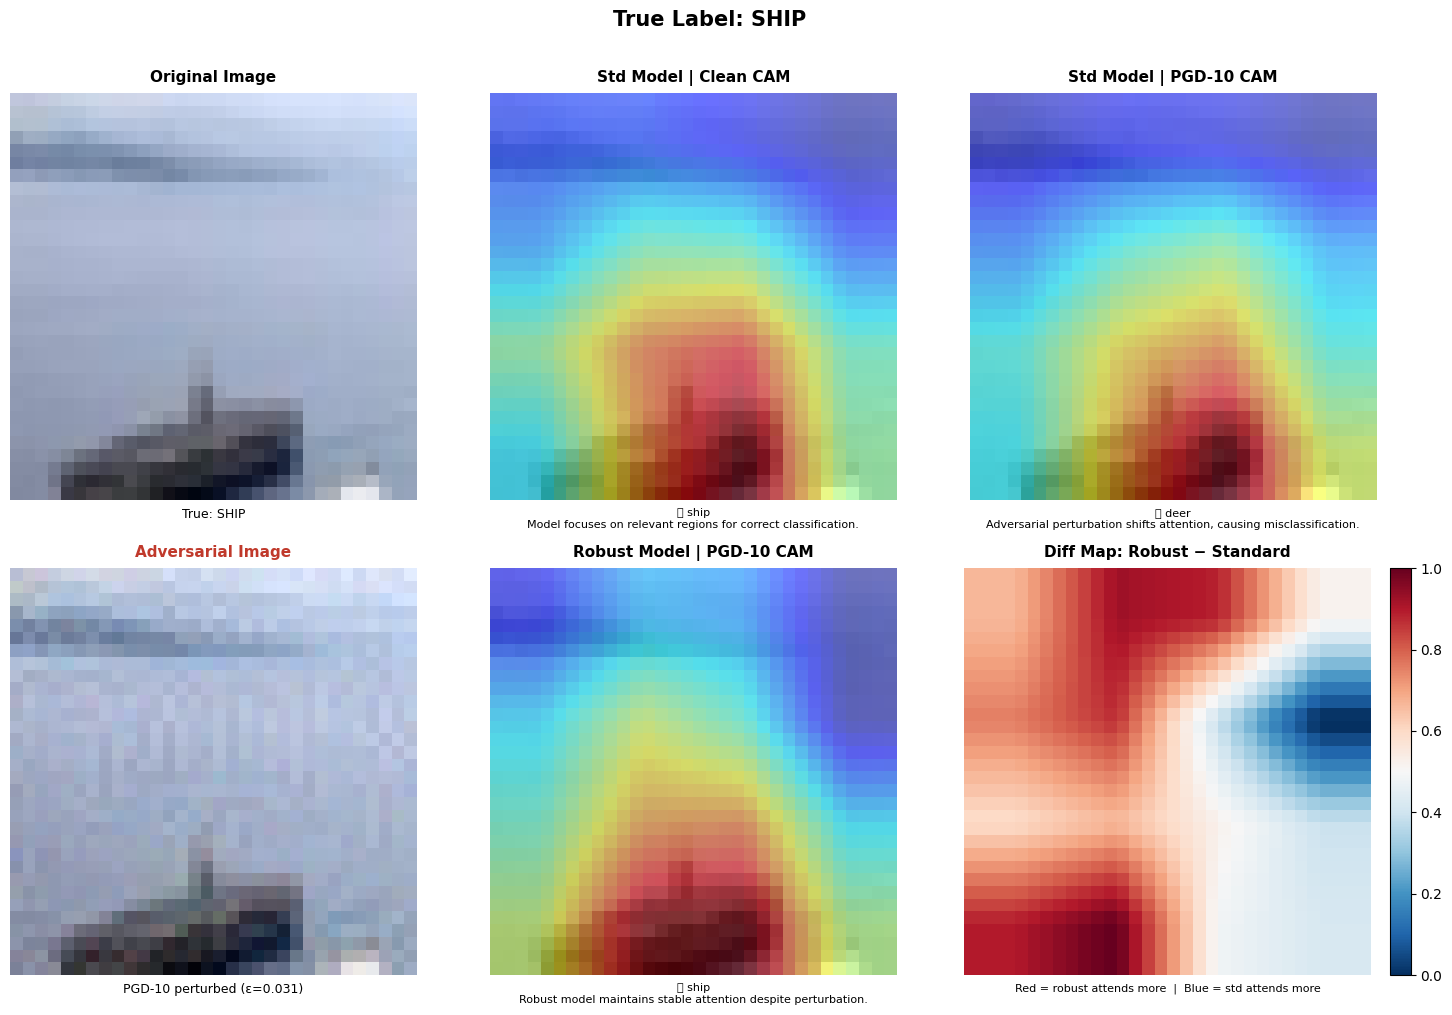

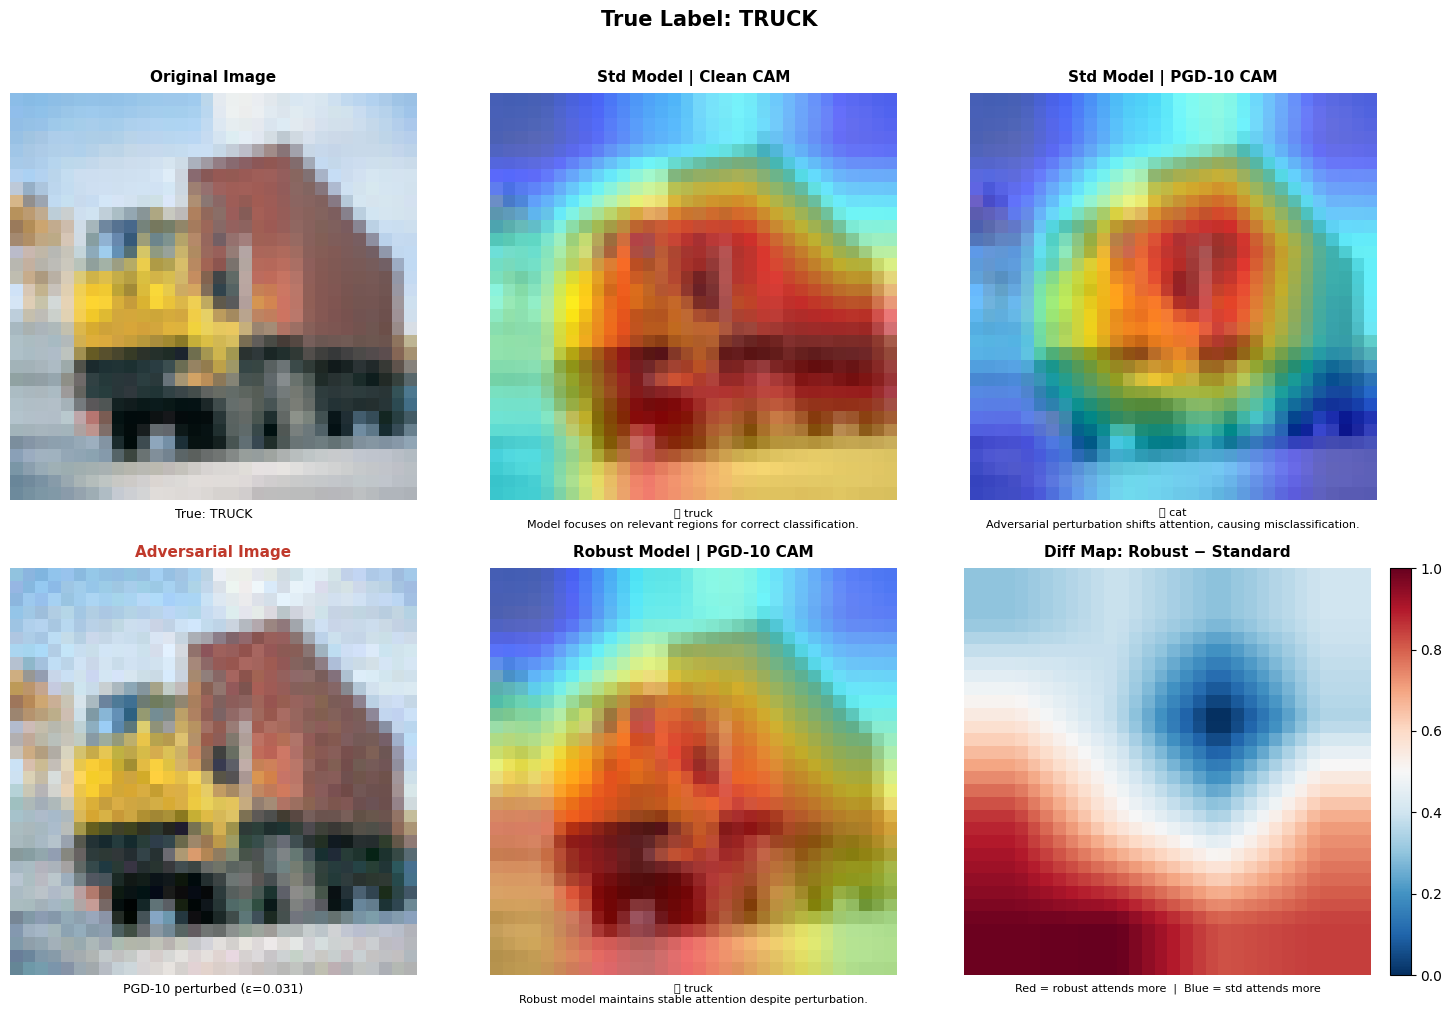

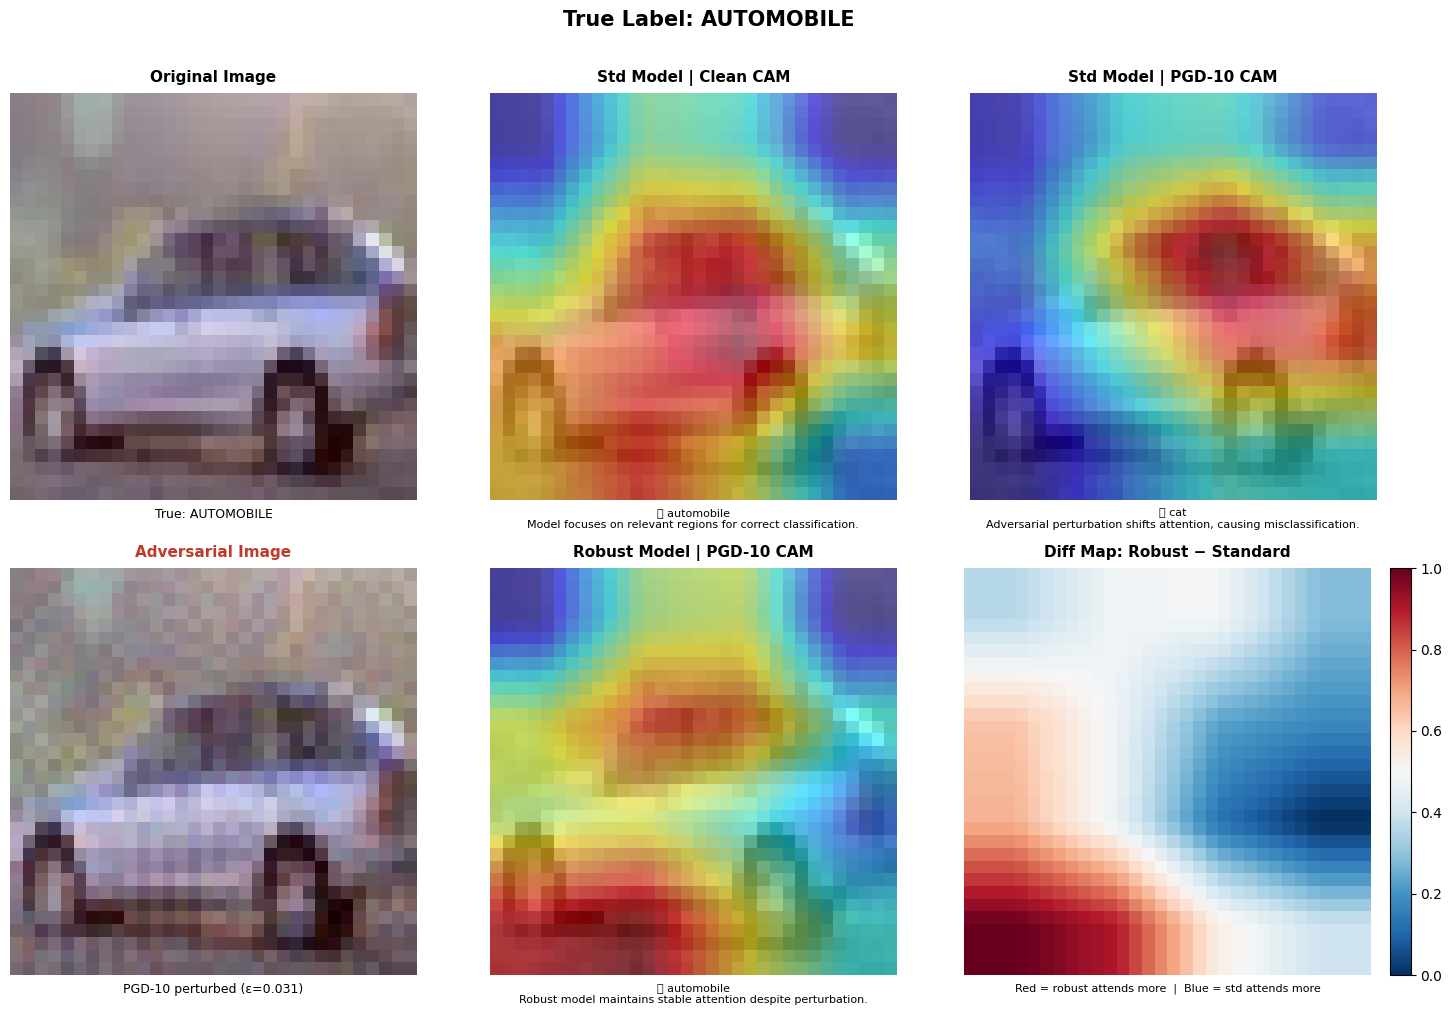

In [30]:
def visualize_scenarios(batch_idx):
    orig_img          = images[batch_idx:batch_idx+1]
    orig_label        = labels[batch_idx].item()
    orig_label_tensor = labels[batch_idx:batch_idx+1]

    adv_img = pgd_attack(standard_model, orig_img, orig_label_tensor)

    clean_pred,   _ = predict(standard_model, orig_img)
    std_adv_pred, _ = predict(standard_model, adv_img)
    rob_adv_pred, _ = predict(robust_model,   adv_img)

    clean_rgb = np.clip(denormalize(orig_img).squeeze().permute(1,2,0).cpu().numpy(), 0, 1)
    adv_rgb   = np.clip(denormalize(adv_img).squeeze().permute(1,2,0).cpu().numpy(),  0, 1)

    heatmap_clean_std, cam_clean_std = generate_heatmap(standard_cam, orig_img, clean_rgb)
    heatmap_adv_std,   cam_adv_std   = generate_heatmap(standard_cam, adv_img,  clean_rgb)
    heatmap_adv_rob,   cam_adv_rob   = generate_heatmap(robust_cam,   adv_img,  clean_rgb)

    diff_map      = cam_adv_rob.astype(np.float32) - cam_adv_std.astype(np.float32)
    diff_map_norm = (diff_map - diff_map.min()) / (diff_map.max() - diff_map.min() + 1e-8)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.subplots_adjust(hspace=0.45, wspace=0.2)

    true_cls = CIFAR10_CLASSES[orig_label].upper()
    fig.suptitle(f'True Label: {true_cls}', fontsize=15, fontweight='bold', y=1.01)

    def fmt(pred):
        ok = '✅' if pred == orig_label else '❌'
        return f'{ok} {CIFAR10_CLASSES[pred]}'

    def clean_ax(ax):
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)

    # ── Row 0 ──

    # [0,0] Original clean image
    axes[0,0].imshow(clean_rgb)
    axes[0,0].set_title('Original Image', fontsize=11, fontweight='bold', pad=8)
    axes[0,0].set_xlabel(f'True: {CIFAR10_CLASSES[orig_label].upper()}', fontsize=9, labelpad=6)
    clean_ax(axes[0,0])

    # [0,1] Standard model — clean CAM
    axes[0,1].imshow(heatmap_clean_std)
    axes[0,1].set_title('Std Model | Clean CAM', fontsize=11, fontweight='bold', pad=8)
    axes[0,1].set_xlabel(fmt(clean_pred) + '\n' + generate_caption(clean_pred == orig_label, False, 'standard'),
                         fontsize=8, labelpad=6)
    clean_ax(axes[0,1])

    # [0,2] Standard model — adversarial CAM
    axes[0,2].imshow(heatmap_adv_std)
    axes[0,2].set_title(f'Std Model | PGD-{PGD_EVAL_STEPS} CAM', fontsize=11, fontweight='bold', pad=8)
    axes[0,2].set_xlabel(fmt(std_adv_pred) + '\n' + generate_caption(std_adv_pred == orig_label, True, 'standard'),
                         fontsize=8, labelpad=6)
    clean_ax(axes[0,2])

    # ── Row 1 ──

    # [1,0] Adversarial image
    axes[1,0].imshow(adv_rgb)
    axes[1,0].set_title('Adversarial Image', fontsize=11, fontweight='bold', pad=8, color='#c0392b')
    axes[1,0].set_xlabel(f'PGD-{PGD_EVAL_STEPS} perturbed (ε={PGD_EPSILON:.3f})', fontsize=9, labelpad=6)
    clean_ax(axes[1,0])

    # [1,1] Robust model — adversarial CAM
    axes[1,1].imshow(heatmap_adv_rob)
    axes[1,1].set_title(f'Robust Model | PGD-{PGD_EVAL_STEPS} CAM', fontsize=11, fontweight='bold', pad=8)
    axes[1,1].set_xlabel(fmt(rob_adv_pred) + '\n' + generate_caption(rob_adv_pred == orig_label, True, 'robust'),
                         fontsize=8, labelpad=6)
    clean_ax(axes[1,1])

    # [1,2] Difference map
    im = axes[1,2].imshow(diff_map_norm, cmap='RdBu_r', vmin=0, vmax=1)
    axes[1,2].set_title('Diff Map: Robust − Standard', fontsize=11, fontweight='bold', pad=8)
    axes[1,2].set_xlabel('Red = robust attends more  |  Blue = std attends more',
                         fontsize=8, labelpad=6)
    clean_ax(axes[1,2])
    plt.colorbar(im, ax=axes[1,2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    return fig, axes


# ── Cases where standard fails BUT robust survives ──
interesting = [
    i for i in range(len(images))
    if predict(standard_model, pgd_attack(standard_model, images[i:i+1], labels[i:i+1]))[0] != labels[i].item()
    and predict(robust_model,  pgd_attack(standard_model, images[i:i+1], labels[i:i+1]))[0] == labels[i].item()
]

for idx in interesting[:3]:
    fig, _ = visualize_scenarios(idx)
    plt.savefig(f'{OUTPUT_DIR}/gradcam_example_{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Cell 7 — Grad-CAM Batch Export
Generate panels for frontend visualization mapping.

In [19]:
print(f"\nExporting Grid Visualizations to {GRADCAM_DIR}...")
for i in range(10):
    fig, _ = visualize_scenarios(i)
    fig.savefig(f'{GRADCAM_DIR}/sample_{i}_gradcam.png', dpi=150, bbox_inches='tight')
    plt.close(fig)
print("Finished saving all Grad-CAM interpretability heatmaps.")


Exporting Grid Visualizations to /kaggle/working/outputs/gradcam...


/tmp/ipykernel_55/1266487698.py:78: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1266487698.py:78: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1372831348.py:4: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(f'{GRADCAM_DIR}/sample_{i}_gradcam.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_55/1372831348.py:4: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(f'{GRADCAM_DIR}/sample_{i}_gradcam.png', dpi=150, bbox_inches='tight')


Finished saving all Grad-CAM interpretability heatmaps.


---
## Cell A — Per-Class Robustness Analysis

Breakdown of PGD-10 accuracy by class for both models. Reveals which object categories are inherently more vulnerable to adversarial perturbations.

In [21]:
# ── Per-class PGD-10 accuracy ──
def per_class_accuracy(model, loader, attack_fn=None, **kwargs):
    """Returns per-class correct/total counts."""
    model.eval()
    class_correct = [0] * 10
    class_total   = [0] * 10
    for images, labels in loader:
        adv = attack_fn(model, images, labels, **kwargs) if attack_fn else images.to(DEVICE)
        with torch.no_grad():
            _, predicted = model(adv).max(1)
        predicted = predicted.cpu()
        for c in range(10):
            mask = labels == c
            class_total[c]   += mask.sum().item()
            class_correct[c] += (predicted[mask] == labels[mask]).sum().item()
    return [100.0 * class_correct[c] / class_total[c] if class_total[c] > 0 else 0.0
            for c in range(10)]

print("Computing per-class PGD-10 accuracy (this may take a minute)...")
std_class_accs = per_class_accuracy(standard_model, test_loader, pgd_attack)
rob_class_accs = per_class_accuracy(robust_model,   test_loader, pgd_attack)

per_class_df = pd.DataFrame({
    'Class'    : CIFAR10_CLASSES,
    'Standard' : [f"{a:.1f}%" for a in std_class_accs],
    'Robust'   : [f"{a:.1f}%" for a in rob_class_accs],
    'Δ (Robust − Standard)': [f"+{r-s:.1f}%" if r >= s else f"{r-s:.1f}%"
                               for s, r in zip(std_class_accs, rob_class_accs)]
})
print("\n── Per-Class PGD-10 Accuracy ──")
print(per_class_df.to_string(index=False))

# Identify weakest & strongest
weak_std  = sorted(zip(std_class_accs, CIFAR10_CLASSES))[:3]
weak_rob  = sorted(zip(rob_class_accs, CIFAR10_CLASSES))[:3]
strong_rob = sorted(zip(rob_class_accs, CIFAR10_CLASSES), reverse=True)[:3]

print(f"\n⚠️  Most vulnerable (Standard model): {[c for _, c in weak_std]}")
print(f"⚠️  Most vulnerable (Robust model)  : {[c for _, c in weak_rob]}")
print(f"✅  Most resilient  (Robust model)  : {[c for _, c in strong_rob]}")

per_class_df.to_csv(f'{OUTPUT_DIR}/per_class_results.csv', index=False)
print(f"\nSaved: {OUTPUT_DIR}/per_class_results.csv")


Computing per-class PGD-10 accuracy (this may take a minute)...

── Per-Class PGD-10 Accuracy ──
     Class Standard Robust Δ (Robust − Standard)
  airplane     0.0%  50.8%                +50.8%
automobile     0.2%  65.8%                +65.6%
      bird     0.0%  29.2%                +29.2%
       cat     0.0%  17.8%                +17.8%
      deer     0.0%  19.6%                +19.6%
       dog     0.0%  34.8%                +34.8%
      frog     0.0%  41.4%                +41.4%
     horse     0.0%  55.6%                +55.6%
      ship     0.0%  55.0%                +55.0%
     truck     0.0%  55.8%                +55.8%

⚠️  Most vulnerable (Standard model): ['airplane', 'bird', 'cat']
⚠️  Most vulnerable (Robust model)  : ['cat', 'deer', 'bird']
✅  Most resilient  (Robust model)  : ['automobile', 'truck', 'horse']

Saved: /kaggle/working/outputs/per_class_results.csv


---
## Cell B — Visual Examples: Clean vs. Adversarial with Prediction Tables

Side-by-side comparison of original and adversarially-perturbed images with model predictions and confidence scores for both models.

/tmp/ipykernel_55/3395421563.py:55: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/3395421563.py:55: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/3395421563.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(f'{OUTPUT_DIR}/visual_examples.png', dpi=200, bbox_inches='tight')
/tmp/ipykernel_55/3395421563.py:56: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(f'{OUTPUT_DIR}/visual_examples.png', dpi=200, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY

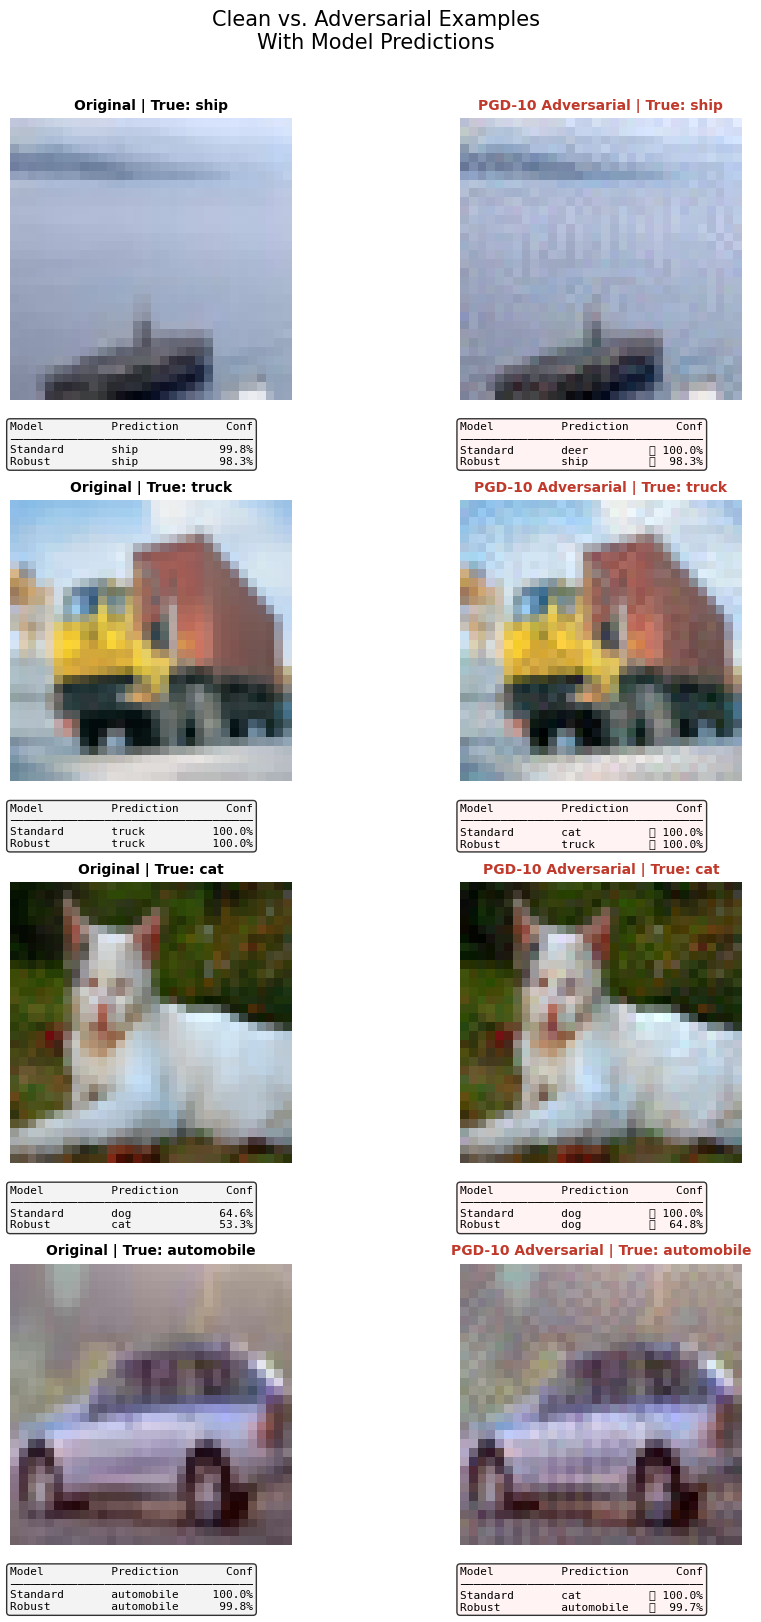

Saved: /kaggle/working/outputs/visual_examples.png


In [24]:
# ── Visual Examples with Prediction Tables ──
demo_images, demo_labels = next(iter(test_loader))
N_DEMO = 4  # Show 4 examples

fig, axes = plt.subplots(N_DEMO, 2, figsize=(10, 4 * N_DEMO))
fig.suptitle("Clean vs. Adversarial Examples\nWith Model Predictions", fontsize=15, y=1.01)

for i in range(N_DEMO):
    orig_img = demo_images[i:i+1]
    orig_lbl = demo_labels[i:i+1]
    true_cls = CIFAR10_CLASSES[demo_labels[i].item()]

    adv_img = pgd_attack(standard_model, orig_img, orig_lbl)

    # Predictions
    std_clean_pred, std_clean_conf = predict(standard_model, orig_img)
    std_adv_pred,   std_adv_conf   = predict(standard_model, adv_img)
    rob_clean_pred, rob_clean_conf = predict(robust_model,   orig_img)
    rob_adv_pred,   rob_adv_conf   = predict(robust_model,   adv_img)

    # Images
    clean_np = np.clip(denormalize(orig_img).squeeze().permute(1,2,0).cpu().numpy(), 0, 1)
    adv_np   = np.clip(denormalize(adv_img).squeeze().permute(1,2,0).cpu().numpy(), 0, 1)

    # Clean panel
    axes[i, 0].imshow(clean_np)
    axes[i, 0].set_title(f'Original | True: {true_cls}', fontsize=10, fontweight='bold')
    axes[i, 0].axis('off')
    table_clean = (
        f"{'Model':<14} {'Prediction':<14} {'Conf':>6}\n"
        f"{'─'*36}\n"
        f"{'Standard':<14} {CIFAR10_CLASSES[std_clean_pred]:<14} {std_clean_conf*100:>5.1f}%\n"
        f"{'Robust':<14} {CIFAR10_CLASSES[rob_clean_pred]:<14} {rob_clean_conf*100:>5.1f}%"
    )
    axes[i, 0].text(0, -0.08, table_clean, transform=axes[i, 0].transAxes,
                    fontsize=8, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

    # Adversarial panel
    axes[i, 1].imshow(adv_np)
    axes[i, 1].set_title(f'PGD-10 Adversarial | True: {true_cls}', fontsize=10, fontweight='bold', color='#c0392b')
    axes[i, 1].axis('off')
    std_mark = '✅' if std_adv_pred == demo_labels[i].item() else '❌'
    rob_mark = '✅' if rob_adv_pred == demo_labels[i].item() else '❌'
    table_adv = (
        f"{'Model':<14} {'Prediction':<14} {'Conf':>6}\n"
        f"{'─'*36}\n"
        f"{'Standard':<14} {CIFAR10_CLASSES[std_adv_pred]:<12} {std_mark} {std_adv_conf*100:>5.1f}%\n"
        f"{'Robust':<14} {CIFAR10_CLASSES[rob_adv_pred]:<12} {rob_mark} {rob_adv_conf*100:>5.1f}%"
    )
    axes[i, 1].text(0, -0.08, table_adv, transform=axes[i, 1].transAxes,
                    fontsize=8, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='#fff0f0', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/visual_examples.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/visual_examples.png")


---
## Cell D — Key Insights & Findings

### Summary of Results

1. **Standard model is highly vulnerable to adversarial attacks.** PGD-10 accuracy collapses near zero at ε=8/255, confirming the brittleness of standard ERM training.

2. **Robust adversarial training significantly improves resilience.** The robust model retains meaningful accuracy under all attack scenarios, demonstrating that adversarial training generalises beyond the specific attack used during training.

3. **Robustness comes with a clean accuracy trade-off.** Adversarial training regularises the model more strongly, resulting in slightly lower clean accuracy — a well-documented phenomenon in the robustness literature.

4. **Certain classes are inherently more vulnerable.** Visually similar categories (e.g., *cat*, *deer*, *bird*) are harder to defend because their decision boundaries are closer in input space, making adversarial examples easier to construct.

5. **Robust models maintain more stable attention under perturbation.** Grad-CAM visualisations show that standard model attention shifts dramatically under adversarial perturbation, while robust model attention remains anchored to semantically meaningful object regions.

### Deployment Readiness

The robust model checkpoint is production-ready and exported below. The evaluation pipeline is fully reproducible and decoupled from training.

---
## Cell E — Export for Deployment

Save model weights and aggregated results for downstream use in FastAPI serving or LLM-based analysis.

In [37]:
import shutil

# ── Model weights ──
robust_export_path   = f'{OUTPUT_DIR}/robust_model.pth'
standard_export_path = f'{OUTPUT_DIR}/standard_model.pth'

torch.save(robust_model.state_dict(),   robust_export_path)
torch.save(standard_model.state_dict(), standard_export_path)
print(f"Saved: {robust_export_path}")
print(f"Saved: {standard_export_path}")

# ── Results JSON (structured for LLM/API consumption) ──
export_payload = {
    "clean_acc_standard"  : results['Clean accuracy']['Standard'],
    "clean_acc_robust"    : results['Clean accuracy']['Robust'],
    "fgsm_acc_standard"   : results['FGSM accuracy (eps=8/255)']['Standard'],
    "fgsm_acc_robust"     : results['FGSM accuracy (eps=8/255)']['Robust'],
    "pgd10_acc_standard"  : results['PGD-10 accuracy (eps=8/255)']['Standard'],
    "pgd10_acc_robust"    : results['PGD-10 accuracy (eps=8/255)']['Robust'],
    "weak_classes_standard": [c for _, c in sorted(zip(std_class_accs, CIFAR10_CLASSES))[:3]],
    "weak_classes_robust"  : [c for _, c in sorted(zip(rob_class_accs, CIFAR10_CLASSES))[:3]],
    "strong_classes_robust": [c for _, c in sorted(zip(rob_class_accs, CIFAR10_CLASSES), reverse=True)[:3]],
    "per_class_standard_pgd10": dict(zip(CIFAR10_CLASSES, std_class_accs)),
    "per_class_robust_pgd10"  : dict(zip(CIFAR10_CLASSES, rob_class_accs)),
}

results_json_path = f'{OUTPUT_DIR}/results.json'
with open(results_json_path, 'w') as f:
    json.dump(export_payload, f, indent=4)
print(f"Saved: {results_json_path}")

print("\n── Export complete. Files ready for FastAPI / LLM pipeline ──")
print(f"  {robust_export_path}")
print(f"  {standard_export_path}")
print(f"  {results_json_path}")
print(f"  {OUTPUT_DIR}/final_results.csv")
print(f"  {OUTPUT_DIR}/per_class_results.csv")


Saved: /kaggle/working/outputs/robust_model.pth
Saved: /kaggle/working/outputs/standard_model.pth
Saved: /kaggle/working/outputs/results.json

── Export complete. Files ready for FastAPI / LLM pipeline ──
  /kaggle/working/outputs/robust_model.pth
  /kaggle/working/outputs/standard_model.pth
  /kaggle/working/outputs/results.json
  /kaggle/working/outputs/final_results.csv
  /kaggle/working/outputs/per_class_results.csv
